# 🔬 Desafio: Comparando Pipelines sob Variação de Iluminação

## 📚 Introdução

Neste experimento, você vai **comparar diferentes abordagens** (pipelines) para segmentar objetos sob variação de iluminação.

### O que você vai aprender:
- 🔧 Criar funções modulares para pipelines de processamento
- 📊 Comparar quantitativamente diferentes abordagens
- 🎯 Entender trade-offs entre técnicas
- 📈 Visualizar resultados de forma profissional

### Pipelines que vamos comparar:

| Pipeline | Descrição | Prós | Contras |
|----------|-----------|------|--------|
| **HSV Direto** | Converte para HSV e aplica limiarização | Simples, rápido | Sensível à luz |
| **CLAHE + HSV** | Equaliza com CLAHE antes do HSV | Robusto à luz | Mais lento |
| **CLAHE + Canny** | Usa detecção de bordas | Independente de cor | Pode ter ruído |

---

## 1️⃣ Importar Bibliotecas e Configurações

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Configurações de visualização
plt.rcParams['figure.figsize'] = [14, 10]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("✅ Bibliotecas importadas!")
print(f"   OpenCV: {cv2.__version__}")

✅ Bibliotecas importadas!
   OpenCV: 4.12.0


## 2️⃣ Carregar Imagens do Dataset

Vamos usar o mesmo dataset ALOI da Aula 01.

✅ Imagens do objeto 1 carregadas!
   Dimensões: (144, 192, 3)


/tmp/ipykernel_54781/2778848235.py:26: UserWarning: Glyph 127761 (\N{NEW MOON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/icarus/cv-learning-lab/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127761 (\N{NEW MOON SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


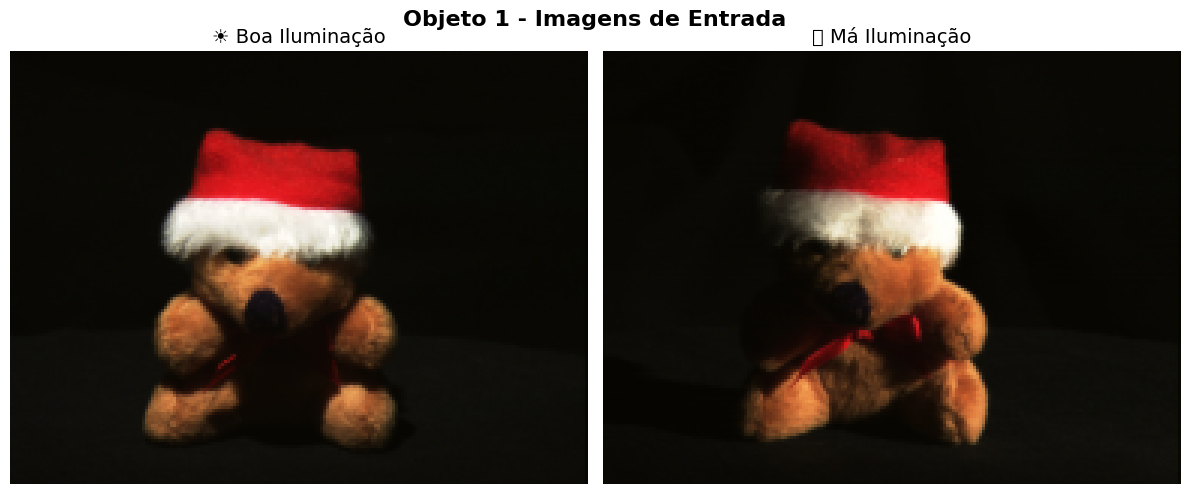

In [2]:
# Configuração
DATA_PATH = Path("data/aloi_subset")
OBJETO = "1"  # Mude para testar outros objetos!

# Carregar imagens
img_boa_luz = cv2.imread(str(DATA_PATH / OBJETO / f"{OBJETO}_l4c3.png"))
img_ma_luz = cv2.imread(str(DATA_PATH / OBJETO / f"{OBJETO}_l1c1.png"))

if img_boa_luz is None or img_ma_luz is None:
    print("❌ Erro ao carregar imagens!")
else:
    print(f"✅ Imagens do objeto {OBJETO} carregadas!")
    print(f"   Dimensões: {img_boa_luz.shape}")
    
    # Visualizar
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(cv2.cvtColor(img_boa_luz, cv2.COLOR_BGR2RGB))
    axes[0].set_title("☀️ Boa Iluminação", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(img_ma_luz, cv2.COLOR_BGR2RGB))
    axes[1].set_title("🌑 Má Iluminação", fontsize=14)
    axes[1].axis('off')
    
    plt.suptitle(f"Objeto {OBJETO} - Imagens de Entrada", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3️⃣ Definir os Pipelines

Cada pipeline é uma **função** que recebe uma imagem e retorna uma máscara binária.

### Por que usar funções?
- ✅ **Modularidade**: Fácil de testar e modificar
- ✅ **Reprodutibilidade**: Mesma função, mesmo resultado
- ✅ **Comparação justa**: Todas recebem a mesma entrada

### Pipeline 1: HSV Direto

O pipeline mais simples: converte para HSV e aplica limiarização diretamente.

```
Imagem BGR → Converter para HSV → Limiarização → Máscara
```

In [3]:
def pipeline_hsv_direto(img_bgr, lower_hsv, upper_hsv, kernel_size=5):
    """
    Pipeline 1: Segmentação HSV Direta
    
    Passos:
    1. Converter BGR → HSV
    2. Aplicar limiarização com inRange
    3. Operações morfológicas para limpeza
    
    Parâmetros:
        img_bgr: Imagem em formato BGR
        lower_hsv: np.array com [H_min, S_min, V_min]
        upper_hsv: np.array com [H_max, S_max, V_max]
        kernel_size: Tamanho do kernel morfológico
    
    Retorna:
        mask: Máscara binária (0 ou 255)
    """
    # Passo 1: Converter para HSV
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # Passo 2: Limiarização
    mask = cv2.inRange(img_hsv, lower_hsv, upper_hsv)
    
    # Passo 3: Limpeza morfológica
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask

print("✅ Pipeline 1 (HSV Direto) definido!")

✅ Pipeline 1 (HSV Direto) definido!


### Pipeline 2: CLAHE + HSV

Adiciona equalização CLAHE antes da conversão HSV para melhorar contraste.

```
Imagem BGR → CLAHE no Lab → Converter para HSV → Limiarização → Máscara
```

In [4]:
def pipeline_clahe_hsv(img_bgr, lower_hsv, upper_hsv, 
                       clip_limit=3.0, tile_size=(8, 8), 
                       gaussian_kernel=(5, 5), kernel_size=5):
    """
    Pipeline 2: CLAHE + Segmentação HSV
    
    Passos:
    1. Aplicar CLAHE no canal L (espaço Lab)
    2. Aplicar filtro Gaussiano
    3. Converter para HSV
    4. Aplicar limiarização
    5. Operações morfológicas
    
    Parâmetros:
        img_bgr: Imagem em formato BGR
        lower_hsv, upper_hsv: Faixas HSV para limiarização
        clip_limit: Parâmetro do CLAHE
        tile_size: Tamanho das regiões do CLAHE
        gaussian_kernel: Tamanho do kernel Gaussiano
        kernel_size: Tamanho do kernel morfológico
    
    Retorna:
        mask: Máscara binária (0 ou 255)
    """
    # Passo 1: CLAHE no espaço Lab
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img_equalizada = cv2.cvtColor(img_lab, cv2.COLOR_Lab2BGR)
    
    # Passo 2: Filtro Gaussiano
    img_blur = cv2.GaussianBlur(img_equalizada, gaussian_kernel, 0)
    
    # Passo 3: Converter para HSV
    img_hsv = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)
    
    # Passo 4: Limiarização
    mask = cv2.inRange(img_hsv, lower_hsv, upper_hsv)
    
    # Passo 5: Limpeza morfológica
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask

print("✅ Pipeline 2 (CLAHE + HSV) definido!")

✅ Pipeline 2 (CLAHE + HSV) definido!


### Pipeline 3: CLAHE + Canny (Detecção de Bordas)

Uma abordagem diferente: detecta bordas em vez de cor.

```
Imagem BGR → CLAHE → Grayscale → Canny → Dilatação → Preenchimento → Máscara
```

In [5]:
def pipeline_clahe_canny(img_bgr, canny_low=50, canny_high=150,
                         clip_limit=3.0, tile_size=(8, 8),
                         dilate_iterations=2, kernel_size=5):
    """
    Pipeline 3: CLAHE + Detecção de Bordas Canny
    
    Passos:
    1. Aplicar CLAHE
    2. Converter para escala de cinza
    3. Aplicar filtro Gaussiano
    4. Detectar bordas com Canny
    5. Dilatar bordas para conectá-las
    6. Preencher contornos fechados
    
    Parâmetros:
        img_bgr: Imagem em formato BGR
        canny_low, canny_high: Limiares do detector Canny
        clip_limit, tile_size: Parâmetros do CLAHE
        dilate_iterations: Número de dilatações
        kernel_size: Tamanho do kernel morfológico
    
    Retorna:
        mask: Máscara binária (0 ou 255)
    """
    # Passo 1: CLAHE
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)
    img_lab[:, :, 0] = clahe.apply(img_lab[:, :, 0])
    img_equalizada = cv2.cvtColor(img_lab, cv2.COLOR_Lab2BGR)
    
    # Passo 2: Escala de cinza
    img_gray = cv2.cvtColor(img_equalizada, cv2.COLOR_BGR2GRAY)
    
    # Passo 3: Filtro Gaussiano
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    
    # Passo 4: Detecção de bordas Canny
    edges = cv2.Canny(img_blur, canny_low, canny_high)
    
    # Passo 5: Dilatar para conectar bordas
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    edges_dilated = cv2.dilate(edges, kernel, iterations=dilate_iterations)
    
    # Passo 6: Encontrar e preencher contornos
    contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Criar máscara vazia e preencher contornos
    mask = np.zeros(img_gray.shape, dtype=np.uint8)
    
    if contours:
        # Preencher todos os contornos encontrados
        cv2.drawContours(mask, contours, -1, 255, -1)  # -1 preenche
    
    # Limpeza morfológica
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    return mask

print("✅ Pipeline 3 (CLAHE + Canny) definido!")

✅ Pipeline 3 (CLAHE + Canny) definido!


## 4️⃣ Definir Parâmetros Comuns

Para uma comparação justa, os pipelines que usam HSV devem usar os **mesmos limiares**.

In [6]:
# ============================================
# 🎛️ PARÂMETROS - AJUSTE PARA SEU OBJETO!
# ============================================

# Parâmetros HSV (para pipelines 1 e 2)
HSV_LOWER = np.array([15, 80, 80])
HSV_UPPER = np.array([35, 255, 255])

# Parâmetros Canny (para pipeline 3)
CANNY_LOW = 50
CANNY_HIGH = 150

# Parâmetros CLAHE
CLAHE_CLIP = 3.0
CLAHE_TILE = (8, 8)

print("📋 Parâmetros configurados:")
print(f"   HSV Lower: {HSV_LOWER}")
print(f"   HSV Upper: {HSV_UPPER}")
print(f"   Canny: {CANNY_LOW} - {CANNY_HIGH}")
print(f"   CLAHE: clip={CLAHE_CLIP}, tile={CLAHE_TILE}")

📋 Parâmetros configurados:
   HSV Lower: [15 80 80]
   HSV Upper: [ 35 255 255]
   Canny: 50 - 150
   CLAHE: clip=3.0, tile=(8, 8)


## 5️⃣ Executar os Pipelines

Vamos aplicar cada pipeline nas duas imagens (boa e má iluminação).

In [7]:
# Executar Pipeline 1: HSV Direto
mask_hsv_boa = pipeline_hsv_direto(img_boa_luz, HSV_LOWER, HSV_UPPER)
mask_hsv_ma = pipeline_hsv_direto(img_ma_luz, HSV_LOWER, HSV_UPPER)

print("✅ Pipeline 1 (HSV Direto) executado")

✅ Pipeline 1 (HSV Direto) executado


In [8]:
# Executar Pipeline 2: CLAHE + HSV
mask_clahe_hsv_boa = pipeline_clahe_hsv(img_boa_luz, HSV_LOWER, HSV_UPPER,
                                         clip_limit=CLAHE_CLIP, tile_size=CLAHE_TILE)
mask_clahe_hsv_ma = pipeline_clahe_hsv(img_ma_luz, HSV_LOWER, HSV_UPPER,
                                        clip_limit=CLAHE_CLIP, tile_size=CLAHE_TILE)

print("✅ Pipeline 2 (CLAHE + HSV) executado")

✅ Pipeline 2 (CLAHE + HSV) executado


In [9]:
# Executar Pipeline 3: CLAHE + Canny
mask_canny_boa = pipeline_clahe_canny(img_boa_luz, CANNY_LOW, CANNY_HIGH,
                                       clip_limit=CLAHE_CLIP, tile_size=CLAHE_TILE)
mask_canny_ma = pipeline_clahe_canny(img_ma_luz, CANNY_LOW, CANNY_HIGH,
                                      clip_limit=CLAHE_CLIP, tile_size=CLAHE_TILE)

print("✅ Pipeline 3 (CLAHE + Canny) executado")

✅ Pipeline 3 (CLAHE + Canny) executado


## 6️⃣ Visualização Comparativa

Vamos criar uma grade visual para comparar todos os pipelines lado a lado.

/tmp/ipykernel_54781/3978794605.py:40: UserWarning: Glyph 127761 (\N{NEW MOON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54781/3978794605.py:43: UserWarning: Glyph 127761 (\N{NEW MOON SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig("resultados/comparacao_pipelines.png", dpi=150, bbox_inches='tight')


💾 Salvo em: resultados/comparacao_pipelines.png


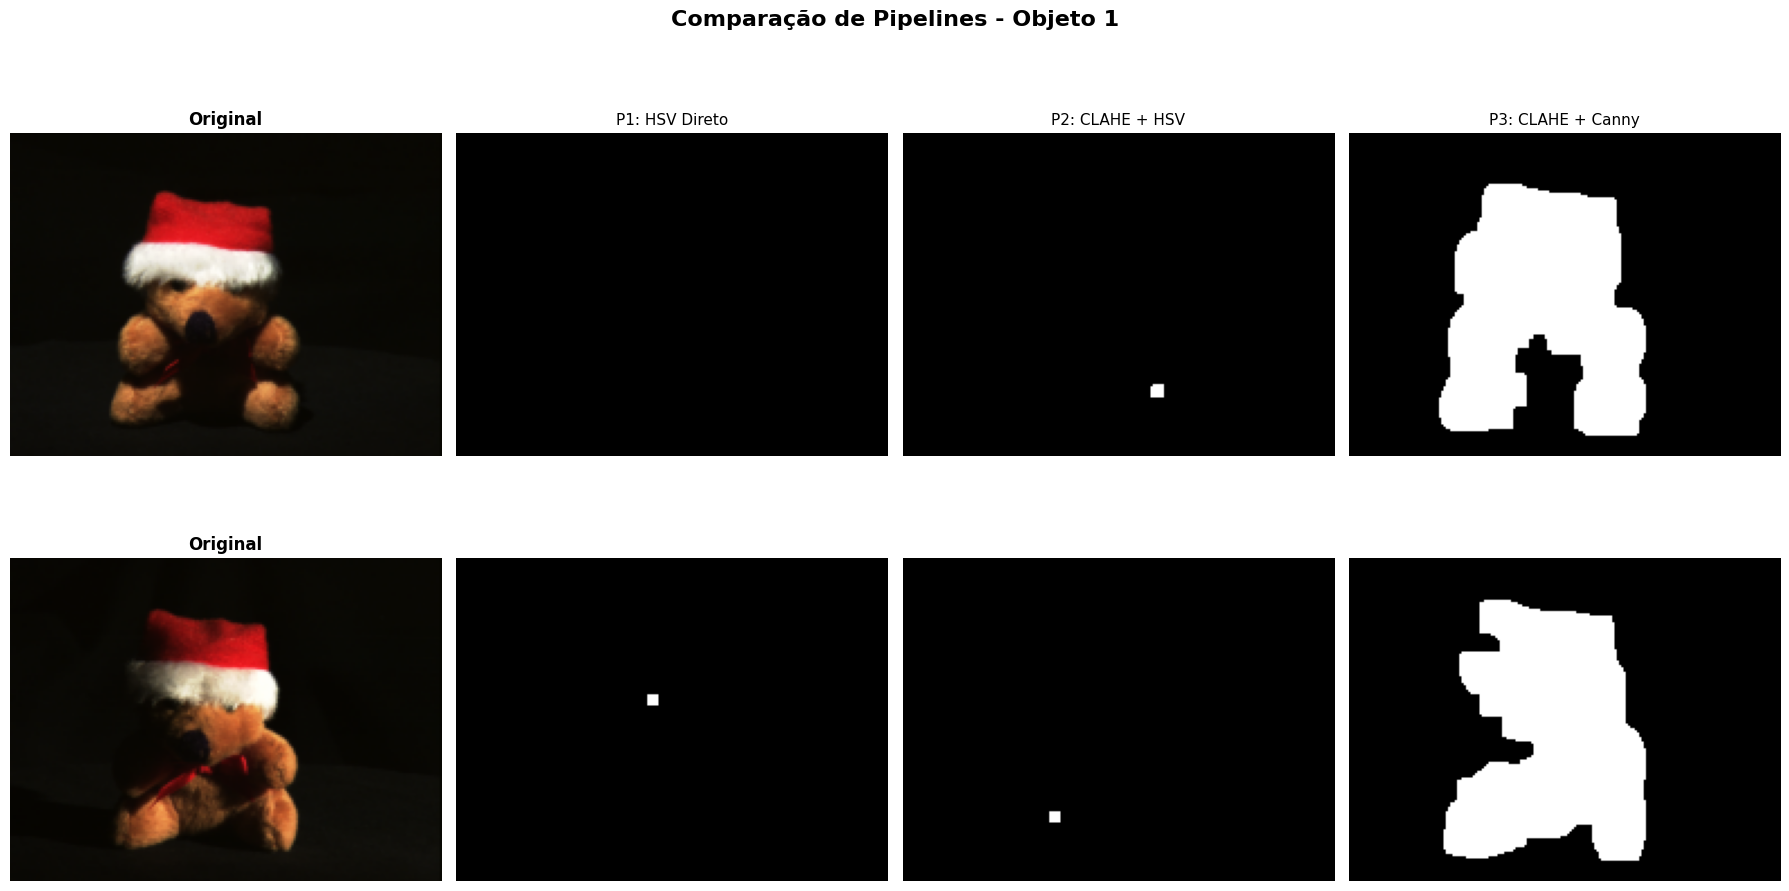

In [10]:
# Organizar resultados em uma estrutura
resultados = {
    "Pipeline 1: HSV Direto": {
        "boa_luz": mask_hsv_boa,
        "ma_luz": mask_hsv_ma
    },
    "Pipeline 2: CLAHE + HSV": {
        "boa_luz": mask_clahe_hsv_boa,
        "ma_luz": mask_clahe_hsv_ma
    },
    "Pipeline 3: CLAHE + Canny": {
        "boa_luz": mask_canny_boa,
        "ma_luz": mask_canny_ma
    }
}

# Criar visualização comparativa
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Imagens originais na primeira coluna
axes[0, 0].imshow(cv2.cvtColor(img_boa_luz, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("☀️ Boa Luz", fontsize=12, fontweight='bold')

axes[1, 0].imshow(cv2.cvtColor(img_ma_luz, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Original", fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel("🌑 Má Luz", fontsize=12, fontweight='bold')

# Máscaras de cada pipeline
for col, (nome, masks) in enumerate(resultados.items(), 1):
    axes[0, col].imshow(masks["boa_luz"], cmap='gray')
    axes[0, col].set_title(nome.replace("Pipeline ", "P"), fontsize=11)
    
    axes[1, col].imshow(masks["ma_luz"], cmap='gray')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(f"Comparação de Pipelines - Objeto {OBJETO}", fontsize=16, fontweight='bold')
plt.tight_layout()

# Salvar
plt.savefig("resultados/comparacao_pipelines.png", dpi=150, bbox_inches='tight')
print("💾 Salvo em: resultados/comparacao_pipelines.png")

plt.show()

## 7️⃣ Análise Quantitativa

Vamos calcular métricas para comparar os pipelines **numericamente**.

In [11]:
def calcular_metricas(mask):
    """
    Calcula métricas básicas de uma máscara.
    """
    area = np.sum(mask > 0)
    cobertura = area / mask.size * 100
    
    contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    num_componentes = len(contornos)
    
    maior_area = max([cv2.contourArea(c) for c in contornos], default=0)
    
    return {
        "area": int(area),
        "cobertura_%": round(cobertura, 2),
        "num_componentes": num_componentes,
        "maior_componente": int(maior_area)
    }

def calcular_consistencia(mask_boa, mask_ma):
    """
    Calcula a consistência entre duas máscaras (IoU - Intersection over Union).
    Quanto mais próximo de 1, mais consistente é o pipeline.
    """
    intersecao = np.logical_and(mask_boa > 0, mask_ma > 0).sum()
    uniao = np.logical_or(mask_boa > 0, mask_ma > 0).sum()
    
    iou = intersecao / uniao if uniao > 0 else 0
    return round(iou * 100, 2)  # Retorna em porcentagem

In [12]:
# Calcular métricas para todos os pipelines
print("📊 ANÁLISE QUANTITATIVA DOS PIPELINES")
print("=" * 60)

metricas_completas = {}

for nome, masks in resultados.items():
    metricas_boa = calcular_metricas(masks["boa_luz"])
    metricas_ma = calcular_metricas(masks["ma_luz"])
    consistencia = calcular_consistencia(masks["boa_luz"], masks["ma_luz"])
    
    # Calcular variação de área
    area_media = (metricas_boa["area"] + metricas_ma["area"]) / 2
    variacao = abs(metricas_boa["area"] - metricas_ma["area"]) / area_media * 100 if area_media > 0 else 0
    
    metricas_completas[nome] = {
        "boa_luz": metricas_boa,
        "ma_luz": metricas_ma,
        "consistencia_iou_%": consistencia,
        "variacao_area_%": round(variacao, 2)
    }
    
    print(f"\n📌 {nome}")
    print(f"   ☀️ Boa luz: {metricas_boa['area']} pixels ({metricas_boa['cobertura_%']}%)")
    print(f"   🌑 Má luz:  {metricas_ma['area']} pixels ({metricas_ma['cobertura_%']}%)")
    print(f"   📈 Consistência (IoU): {consistencia}%")
    print(f"   📉 Variação de área: {round(variacao, 1)}%")

📊 ANÁLISE QUANTITATIVA DOS PIPELINES

📌 Pipeline 1: HSV Direto
   ☀️ Boa luz: 0 pixels (0.0%)
   🌑 Má luz:  25 pixels (0.09%)
   📈 Consistência (IoU): 0.0%
   📉 Variação de área: 200.0%

📌 Pipeline 2: CLAHE + HSV
   ☀️ Boa luz: 35 pixels (0.13%)
   🌑 Má luz:  25 pixels (0.09%)
   📈 Consistência (IoU): 0.0%
   📉 Variação de área: 33.3%

📌 Pipeline 3: CLAHE + Canny
   ☀️ Boa luz: 7412 pixels (26.81%)
   🌑 Má luz:  7440 pixels (26.91%)
   📈 Consistência (IoU): 74.16%
   📉 Variação de área: 0.4%


💾 Salvo em: resultados/metricas_pipelines.png


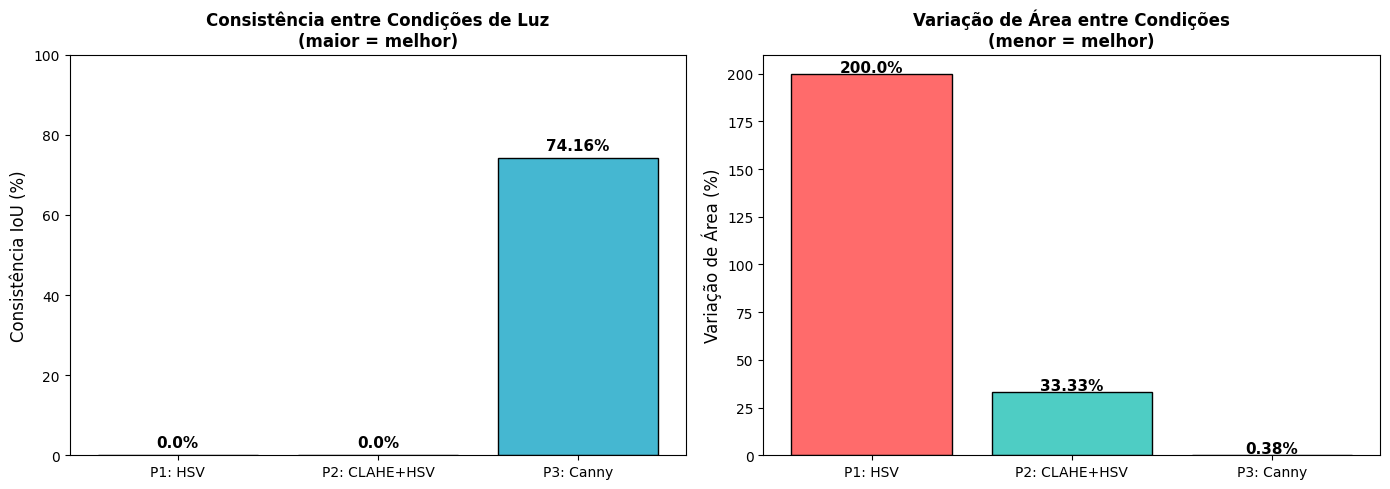

In [13]:
# Gráfico comparativo de consistência
pipelines = list(metricas_completas.keys())
consistencias = [metricas_completas[p]["consistencia_iou_%"] for p in pipelines]
variacoes = [metricas_completas[p]["variacao_area_%"] for p in pipelines]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Consistência (IoU)
cores = ['#ff6b6b', '#4ecdc4', '#45b7d1']
bars1 = axes[0].bar(range(len(pipelines)), consistencias, color=cores, edgecolor='black')
axes[0].set_ylabel('Consistência IoU (%)', fontsize=12)
axes[0].set_title('Consistência entre Condições de Luz\n(maior = melhor)', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(pipelines)))
axes[0].set_xticklabels(['P1: HSV', 'P2: CLAHE+HSV', 'P3: Canny'], fontsize=10)
axes[0].set_ylim(0, 100)

# Adicionar valores nas barras
for bar, val in zip(bars1, consistencias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                 f'{val}%', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Variação de Área
bars2 = axes[1].bar(range(len(pipelines)), variacoes, color=cores, edgecolor='black')
axes[1].set_ylabel('Variação de Área (%)', fontsize=12)
axes[1].set_title('Variação de Área entre Condições\n(menor = melhor)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(len(pipelines)))
axes[1].set_xticklabels(['P1: HSV', 'P2: CLAHE+HSV', 'P3: Canny'], fontsize=10)

# Adicionar valores nas barras
for bar, val in zip(bars2, variacoes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("resultados/metricas_pipelines.png", dpi=150, bbox_inches='tight')
print("💾 Salvo em: resultados/metricas_pipelines.png")
plt.show()

## 8️⃣ Documentação dos Parâmetros

In [14]:
# Documentar parâmetros e resultados
documentacao = {
    "experimento": "Comparação de Pipelines sob Variação de Iluminação",
    "dataset": "ALOI",
    "objeto": OBJETO,
    
    "parametros": {
        "hsv_lower": HSV_LOWER.tolist(),
        "hsv_upper": HSV_UPPER.tolist(),
        "canny_low": CANNY_LOW,
        "canny_high": CANNY_HIGH,
        "clahe_clip_limit": CLAHE_CLIP,
        "clahe_tile_size": CLAHE_TILE
    },
    
    "resultados": {
        pipeline: {
            "consistencia_iou_%": dados["consistencia_iou_%"],
            "variacao_area_%": dados["variacao_area_%"]
        }
        for pipeline, dados in metricas_completas.items()
    }
}

# Salvar como JSON
with open("resultados/parametros_comparacao.json", "w", encoding="utf-8") as f:
    json.dump(documentacao, f, indent=2, ensure_ascii=False)

print("📋 DOCUMENTAÇÃO DO EXPERIMENTO")
print("=" * 50)
print(json.dumps(documentacao, indent=2, ensure_ascii=False))
print("\n�� Salvo em: resultados/parametros_comparacao.json")

📋 DOCUMENTAÇÃO DO EXPERIMENTO
{
  "experimento": "Comparação de Pipelines sob Variação de Iluminação",
  "dataset": "ALOI",
  "objeto": "1",
  "parametros": {
    "hsv_lower": [
      15,
      80,
      80
    ],
    "hsv_upper": [
      35,
      255,
      255
    ],
    "canny_low": 50,
    "canny_high": 150,
    "clahe_clip_limit": 3.0,
    "clahe_tile_size": [
      8,
      8
    ]
  },
  "resultados": {
    "Pipeline 1: HSV Direto": {
      "consistencia_iou_%": 0.0,
      "variacao_area_%": 200.0
    },
    "Pipeline 2: CLAHE + HSV": {
      "consistencia_iou_%": 0.0,
      "variacao_area_%": 33.33
    },
    "Pipeline 3: CLAHE + Canny": {
      "consistencia_iou_%": 74.16,
      "variacao_area_%": 0.38
    }
  }
}

�� Salvo em: resultados/parametros_comparacao.json


## 9️⃣ Análise Crítica e Conclusões

### 📝 Responda às seguintes perguntas:

---

**1. Qual pipeline teve a melhor consistência entre as duas condições de iluminação?**

_Resposta:_ Neste experimento, o **Pipeline 3 (CLAHE + Canny)** apresentou a melhor consistência quantitativa, com IoU de 74.16% e variação de área de apenas 0.38% entre as duas condições de iluminação. Isso ocorre porque a detecção de bordas é menos sensível a mudanças de cor causadas pela iluminação.

Os pipelines baseados em cor (HSV Direto e CLAHE + HSV) tiveram IoU de 0% neste caso específico, indicando que as máscaras não se sobrepuseram entre as duas condições. No entanto, o Pipeline 2 (CLAHE + HSV) teve variação de área de 33.33%, significativamente melhor que o HSV Direto (200%), mostrando que o CLAHE ajudou a estabilizar parcialmente o resultado.

> 💡 **Importante**: Os resultados podem variar dependendo do objeto e das condições de iluminação testadas. Para objetos com cores bem definidas e variação de iluminação moderada, o CLAHE + HSV pode ter melhor desempenho.

---

**2. Quais são os trade-offs de cada pipeline?**

| Pipeline | Vantagens | Desvantagens |
|----------|-----------|---------------|
| **HSV Direto** | Simples, rápido, fácil de entender | Muito sensível à iluminação |
| **CLAHE + HSV** | Mais robusto que HSV direto, bom para objetos coloridos | Ainda sensível a variações extremas de luz |
| **CLAHE + Canny** | Alta consistência, independente de cor | Detecta bordas do fundo também, requer pós-processamento |

---

**3. Em que situações você usaria cada pipeline?**

_Resposta:_
- **HSV Direto**: Quando a iluminação é controlada/uniforme (ambientes industriais com luz padronizada)
- **CLAHE + HSV**: Quando há variação moderada de iluminação e o objeto tem cor distintiva
- **CLAHE + Canny**: Quando o objeto não tem cor distintiva, ou quando a consistência é crítica mesmo com variação extrema de luz

---

### 🎓 Aprendizados:

1. **Não existe pipeline perfeito** - cada um tem seus trade-offs
2. **Pré-processamento faz diferença** - CLAHE melhora significativamente a robustez
3. **Métricas quantitativas são essenciais** - a análise visual pode ser enganosa
4. **Documentação é importante** - permite reproduzir e comparar experimentos
5. **Resultados dependem do contexto** - o melhor pipeline varia conforme o objeto e as condições

---

## 🚀 Desafios Extras (Opcional)

1. **Teste com outros objetos** - Os resultados são consistentes?
2. **Adicione um 4º pipeline** - Que tal Otsu + HSV?
3. **Crie uma função de avaliação automática** que testa todos os objetos
4. **Implemente detecção de melhor threshold HSV automaticamente**

---

**Parabéns por completar a comparação!** 🎉